# Notebook 03 — Annual Discharge at L6 and L8

**Variable**: `dis_m3_pyr` — mean annual discharge at basin outlet (m³/s). Cumulative: includes all upstream inflow. No upstream variant exists — the variable is already an upstream aggregate.

**Goal**: Compare spatial autocorrelation structure of discharge against aridity. The two variables differ fundamentally:
- **Aridity**: driven by continental climate gradients → smooth, spatially coherent field → very high I
- **Discharge**: driven by upstream accumulation along river networks → adjacent basins within the same river corridor are similar; basins straddling watershed divides may be very different → I is an open empirical question

**Key difference from aridity notebooks**: the log transform matters here. `dis_m3_pyr` has skewness ~41 (mean 264 m³/s, median 5.7 m³/s — the Amazon and Congo dominate the tail). Running LISA on raw values produces results reflecting Amazon basin geometry, not the global spatial structure. We run both raw and log global I upfront, then use log as the canonical transform for LISA.

**L6 reference (aridity)**: I_raw=0.9628, I_log=0.9731

**Structure**: Part 1 = L6, Part 2 = L8, Part 3 = cross-scale comparison.

In [1]:
# Cell 2 — imports + timing
import time

def elapsed(t0, label=''):
    m, s = divmod(time.time() - t0, 60)
    print(f'{label}  [{int(m)}m {s:.0f}s]')

%matplotlib inline
import sys
sys.path.insert(0, '/Users/karlg/Documents/repos/_cedop')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely import wkt

import libpysal
from libpysal.weights import Queen
from esda.moran import Moran, Moran_Local

from scripts.shared.db_utils import db_connect

print('Imports OK')

SIGNIFICANCE = 0.05
SEED = 42
COLOURS = {'HH': '#e41a1c', 'LL': '#4575b4', 'LH': '#fdae61', 'HL': '#abd9e9', 'NS': '#d9d9d9'}
quad_map = {1: 'HH', 2: 'LH', 3: 'LL', 4: 'HL'}

/Users/karlg/venvs/cedop/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## Part 1 — L6 (16,397 basins)

### Step 1 — Load data

In [2]:
# Cell 4 — load L6 basin geometry + discharge
t0 = time.time()
conn = db_connect()

SQL = """
SELECT hybas_id, dis_m3_pyr, ST_AsText(geom) AS geom_wkt
FROM public.basin06
ORDER BY hybas_id
"""

with conn.cursor() as cur:
    cur.execute(SQL)
    rows = cur.fetchall()
conn.close()
elapsed(t0, 'L6 fetch')

df6 = pd.DataFrame(rows, columns=['hybas_id', 'dis_m3_pyr', 'geom_wkt'])
df6['geometry'] = df6['geom_wkt'].apply(wkt.loads)
df6 = df6.drop(columns='geom_wkt')
gdf6 = gpd.GeoDataFrame(df6, geometry='geometry', crs='EPSG:4326').set_index('hybas_id')

print(f'{len(gdf6):,} basins loaded')
print(f'Missing discharge: {gdf6["dis_m3_pyr"].isna().sum()}')

16,397 basins loaded
Missing discharge: 0


### Step 2 — Distribution

Discharge is the most right-skewed variable in the dataset. Raw values span ~6 orders of magnitude; a log transform is necessary before any meaningful spatial analysis. The raw histogram will show almost everything in the first bin.

Note: `log1p(0) = 0` — zero-discharge basins (endorheic, hyperarid) map cleanly to zero in log space.

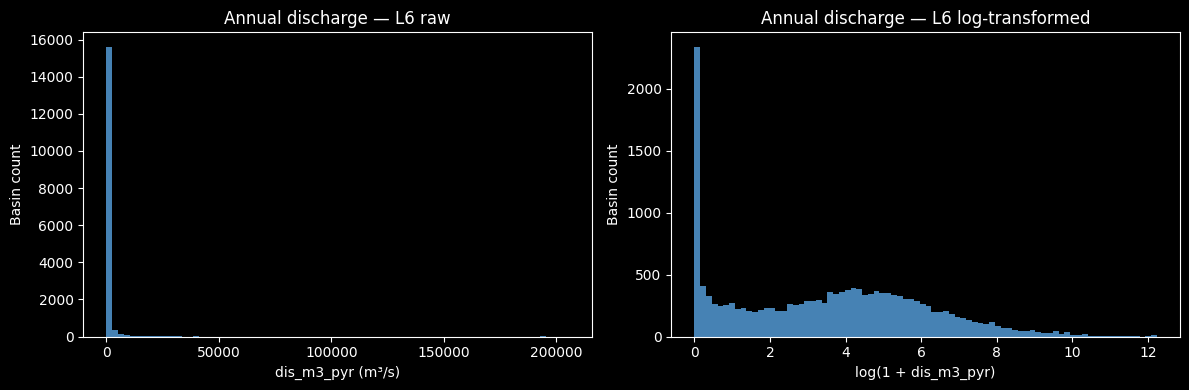

In [3]:
# Cell 6 — distribution: raw and log
dis6 = gdf6['dis_m3_pyr'].dropna().values.astype(float)
dis6_log = np.log1p(dis6)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(dis6, bins=80, color='steelblue', edgecolor='none')
axes[0].set_xlabel('dis_m3_pyr (m³/s)')
axes[0].set_ylabel('Basin count')
axes[0].set_title('Annual discharge — L6 raw')

axes[1].hist(dis6_log, bins=80, color='steelblue', edgecolor='none')
axes[1].set_xlabel('log(1 + dis_m3_pyr)')
axes[1].set_ylabel('Basin count')
axes[1].set_title('Annual discharge — L6 log-transformed')

plt.tight_layout()

print('L6 discharge distribution:')
print(f'  Mean:   {dis6.mean():,.1f} m³/s')
print(f'  Median: {np.median(dis6):,.1f} m³/s')
print(f'  Max:    {dis6.max():,.1f} m³/s  (Amazon outlet)')
print(f'  Zero discharge: {(dis6 == 0).sum():,} basins ({(dis6 == 0).mean()*100:.1f}%)')
print(f'  Skewness (raw): {pd.Series(dis6).skew():.1f}')
print(f'  Skewness (log): {pd.Series(dis6_log).skew():.2f}')

### Step 3 — Spatial weights

Same queen contiguity approach as aridity. The basin geometry is identical — only the variable values differ.

In [4]:
# Cell 8 — queen weights L6
print('Building queen weights for L6...')
t0 = time.time()
w6 = Queen.from_dataframe(gdf6, use_index=True, silence_warnings=True)
w6.transform = 'r'
elapsed(t0, 'L6 weights')
print(f'n={w6.n:,}  mean neighbours={w6.mean_neighbors:.2f}')

L6 weights   38s]
n=16,397  mean neighbours=5.57


### Step 4 — Global Moran's I: raw and log

For aridity, raw vs log differed by 0.010. For discharge, the difference will be larger. We run both here before committing to a transform for LISA.

Expected direction: log I > raw I, because the Amazon/Congo outliers inflate the raw spatial variance without reflecting the general network topology. The log-transformed version compresses the extreme tail and gives equal weight to small-stream and large-river spatial patterns.

In [5]:
# Cell 10 — global Moran's I: raw and log
assert len(gdf6) == w6.n

y6_raw = gdf6['dis_m3_pyr'].values.astype(float)
y6_log = np.log1p(y6_raw)

t0 = time.time()
np.random.seed(SEED)
mi6_raw = Moran(y6_raw, w6, permutations=999)
np.random.seed(SEED)
mi6_log = Moran(y6_log, w6, permutations=999)
elapsed(t0, 'Global I (both transforms)')

print(f"Moran's I (raw):             {mi6_raw.I:.4f}   p={mi6_raw.p_sim:.4f}")
print(f"Moran's I (log-transformed): {mi6_log.I:.4f}   p={mi6_log.p_sim:.4f}")
print(f'Δ (log − raw):               {mi6_log.I - mi6_raw.I:+.4f}')
print()
print('Compare — aridity L6: raw=0.9628, log=0.9731, Δ=+0.010')
print()
print('Log transform is canonical for LISA (steps 5–6).')

Global I (both transforms)   0s]
Moran's I (raw):             0.3986   p=0.0010
Moran's I (log-transformed): 0.5822   p=0.0010
Δ (log − raw):               +0.1836

Compare — aridity L6: raw=0.9628, log=0.9731, Δ=+0.010

Log transform is canonical for LISA (steps 5–6).


### Step 5 — Moran scatter plot (log-transformed)

The scatter plot on log-transformed discharge will show the spatial structure clearly. Expect:
- Dense LL cluster near the origin: small headwater basins surrounded by other small basins
- Elongated HH tail: large river basins (Amazon, Congo, Yangtze) with large-river neighbours
- Possibly more off-diagonal scatter than aridity: watershed divides place dissimilar basins in queen-contiguity

If discharge I is lower than aridity, more scatter around the regression line is the visual cause.

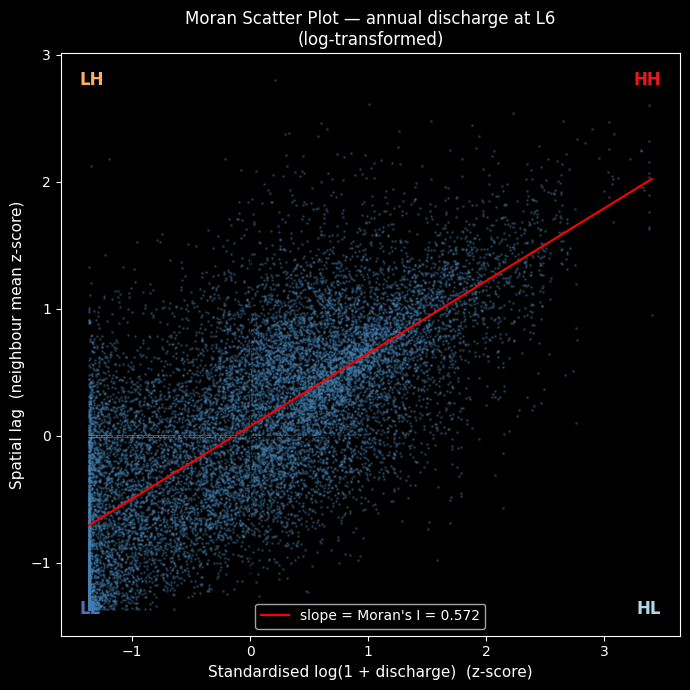

In [6]:
# Cell 12 — Moran scatter plot (log)
y6_std = (y6_log - y6_log.mean()) / y6_log.std()
wy6    = libpysal.weights.lag_spatial(w6, y6_std)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y6_std, wy6, s=1, alpha=0.3, color='steelblue')

m, b = np.polyfit(y6_std, wy6, 1)
x_line = np.linspace(y6_std.min(), y6_std.max(), 200)
ax.plot(x_line, m * x_line + b, color='red', linewidth=1.5,
        label=f"slope = Moran's I = {m:.3f}")

ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
ax.axvline(0, color='black', linewidth=0.7, linestyle='--')

ax.text(0.97, 0.97, 'HH', transform=ax.transAxes, ha='right', va='top',    fontsize=12, color='#e41a1c', fontweight='bold')
ax.text(0.03, 0.97, 'LH', transform=ax.transAxes, ha='left',  va='top',    fontsize=12, color='#fdae61', fontweight='bold')
ax.text(0.97, 0.03, 'HL', transform=ax.transAxes, ha='right', va='bottom', fontsize=12, color='#abd9e9', fontweight='bold')
ax.text(0.03, 0.03, 'LL', transform=ax.transAxes, ha='left',  va='bottom', fontsize=12, color='#4575b4', fontweight='bold')

ax.set_xlabel('Standardised log(1 + discharge)  (z-score)', fontsize=11)
ax.set_ylabel('Spatial lag  (neighbour mean z-score)', fontsize=11)
ax.set_title('Moran Scatter Plot — annual discharge at L6\n(log-transformed)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
print(f'Slope = {m:.4f}  (should equal Moran I log: {mi6_log.I:.4f})')

### Step 6 — LISA (log-transformed)

LISA classes for discharge:
- **HH** — high-discharge basin surrounded by high-discharge basins: major river mainstems (Amazon, Congo, Ganges-Brahmaputra, Mississippi)
- **LL** — low-discharge basin surrounded by low-discharge basins: arid/hyperarid regions, endorheic basins
- **HL** — high-discharge outlier in low-discharge surroundings: a large river entering a dry region (Nile in the Sahara, Amu Darya, Colorado lower reaches)
- **LH** — low-discharge outlier in high-discharge surroundings: a small headwater or endorheic basin embedded in a wet, high-flow region — rare but possible in topographically complex areas

In [7]:
# Cell 14 — LISA L6 (log-transformed)
t0 = time.time()
np.random.seed(SEED)
lisa6 = Moran_Local(y6_log, w6, permutations=999)
elapsed(t0, 'LISA L6')

labels6 = np.where(
    lisa6.p_sim < SIGNIFICANCE,
    np.array([quad_map[q] for q in lisa6.q]),
    'NS'
)
gdf6['lisa_class'] = labels6
gdf6['lisa_p']     = lisa6.p_sim
gdf6['lisa_I']     = lisa6.Is

counts6 = pd.Series(labels6).value_counts().reindex(['HH', 'LL', 'HL', 'LH', 'NS'], fill_value=0)
n6 = len(gdf6)
print('LISA L6 — log discharge (p < 0.05):')
for cls, n in counts6.items():
    print(f'  {cls}: {n:5,}  ({n / n6 * 100:.1f}%)')
print(f'  Total significant: {(labels6 != "NS").sum():,}  ({(labels6 != "NS").mean()*100:.1f}%)')

/Users/karlg/venvs/cedop/lib/python3.14/site-packages/esda/moran.py:1354: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim


### Step 7 — LISA cluster map L6

The cluster map should be geographically interpretable in terms of river systems, not climate zones. Look for:
- HH (red) tracing the Amazon, Congo, Ganges-Brahmaputra, Yangtze, Ob-Irtysh, Mississippi-Missouri corridors
- LL (blue) filling the Sahara, Arabia, Central Asia, Australian interior, Atacama
- HL (light blue) marking rivers that cut through dry regions — classic examples: Nile through Sahara, Amu Darya through Central Asia, Colorado through the Sonoran desert
- LH (orange) marking isolated dry/endorheic basins within otherwise wet regions

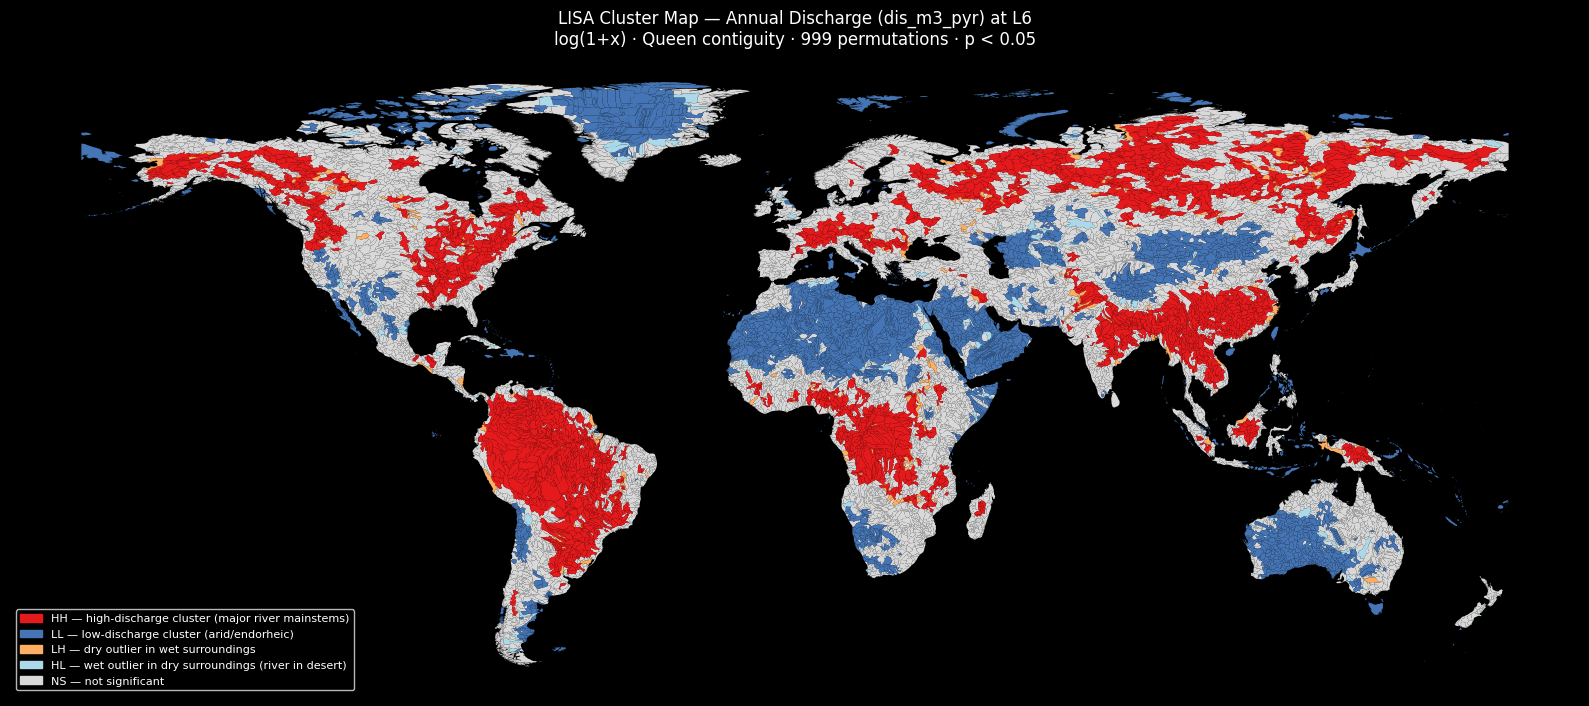

In [8]:
# Cell 16 — LISA cluster map L6
fig, ax = plt.subplots(figsize=(16, 9))
gdf6[gdf6['lisa_class'] == 'NS'].plot(ax=ax, color=COLOURS['NS'], linewidth=0)
for cls in ['LL', 'HH', 'HL', 'LH']:
    subset = gdf6[gdf6['lisa_class'] == cls]
    if len(subset):
        subset.plot(ax=ax, color=COLOURS[cls], linewidth=0)

legend_entries = {
    'HH — high-discharge cluster (major river mainstems)': COLOURS['HH'],
    'LL — low-discharge cluster (arid/endorheic)':         COLOURS['LL'],
    'LH — dry outlier in wet surroundings':                COLOURS['LH'],
    'HL — wet outlier in dry surroundings (river in desert)': COLOURS['HL'],
    'NS — not significant':                                COLOURS['NS'],
}
patches = [mpatches.Patch(color=c, label=l) for l, c in legend_entries.items()]
ax.legend(handles=patches, loc='lower left', fontsize=8, framealpha=0.9)
ax.set_title(
    'LISA Cluster Map — Annual Discharge (dis_m3_pyr) at L6\n'
    'log(1+x) · Queen contiguity · 999 permutations · p < 0.05',
    fontsize=12
)
ax.axis('off')
plt.tight_layout()
plt.savefig('/Users/karlg/Documents/repos/_cedop/spatial/basin06_queen_lisa_dis_python.png',
            dpi=150, bbox_inches='tight')
print('Saved → spatial/basin06_queen_lisa_dis_python.png')

### Step 8 — L6 summary

Baseline row for `variable_characterization.csv`. Compare with aridity L6 (I_raw=0.9628, I_log=0.9731, HH=4.6%, LL=30.0%, HL=1.4%).

In [9]:
# Cell 18 — L6 summary
hh6 = (gdf6['lisa_class'] == 'HH').sum() / n6 * 100
ll6 = (gdf6['lisa_class'] == 'LL').sum() / n6 * 100
hl6 = (gdf6['lisa_class'] == 'HL').sum() / n6 * 100
lh6 = (gdf6['lisa_class'] == 'LH').sum() / n6 * 100
ns6 = (gdf6['lisa_class'] == 'NS').sum() / n6 * 100

ARI_L6 = dict(I_raw=0.9628, I_log=0.9731, HH=4.6, LL=30.0, HL=1.4, LH=0.0, NS=64.0)

print('=== L6 summary — dis_m3_pyr (log) vs aridity (log) ===')
print(f'{"":30s}  {"discharge":>12}  {"aridity":>10}')
print('-' * 57)
print(f'{"Moran I (raw)":30s}  {mi6_raw.I:>12.4f}  {ARI_L6["I_raw"]:>10.4f}')
print(f'{"Moran I (log)":30s}  {mi6_log.I:>12.4f}  {ARI_L6["I_log"]:>10.4f}')
print(f'{"Δ (log−raw)":30s}  {mi6_log.I - mi6_raw.I:>+12.4f}  {ARI_L6["I_log"] - ARI_L6["I_raw"]:>+10.4f}')
print(f'{"HH %":30s}  {hh6:>12.1f}  {ARI_L6["HH"]:>10.1f}')
print(f'{"LL %":30s}  {ll6:>12.1f}  {ARI_L6["LL"]:>10.1f}')
print(f'{"HL %":30s}  {hl6:>12.1f}  {ARI_L6["HL"]:>10.1f}')
print(f'{"LH %":30s}  {lh6:>12.1f}  {ARI_L6["LH"]:>10.1f}')
print(f'{"NS %":30s}  {ns6:>12.1f}  {ARI_L6["NS"]:>10.1f}')

=== L6 summary — dis_m3_pyr (log) vs aridity (log) ===
                                   discharge     aridity
---------------------------------------------------------
Moran I (raw)                         0.3986      0.9628
Moran I (log)                         0.5822      0.9731
Δ (log−raw)                          +0.1836     +0.0103
HH %                                    20.4         4.6
LL %                                    18.9        30.0
HL %                                     0.8         1.4
LH %                                     1.8         0.0
NS %                                    58.1        64.0


---
## Part 2 — L8 (190,675 basins)

### Step 9 — Load data and distribution

In [10]:
# Cell 20 — load L8 basin geometry + discharge
t0 = time.time()
conn = db_connect()
SQL = """
SELECT hybas_id, dis_m3_pyr, ST_AsText(geom) AS geom_wkt
FROM public.basin08
ORDER BY hybas_id
"""
with conn.cursor() as cur:
    cur.execute(SQL)
    rows = cur.fetchall()
conn.close()
elapsed(t0, 'L8 fetch')

df8 = pd.DataFrame(rows, columns=['hybas_id', 'dis_m3_pyr', 'geom_wkt'])
df8['geometry'] = df8['geom_wkt'].apply(wkt.loads)
df8 = df8.drop(columns='geom_wkt')
gdf8 = gpd.GeoDataFrame(df8, geometry='geometry', crs='EPSG:4326').set_index('hybas_id')

dis8 = gdf8['dis_m3_pyr'].dropna().values.astype(float)
print(f'{len(gdf8):,} basins loaded')
print(f'Missing discharge: {gdf8["dis_m3_pyr"].isna().sum()}')
print()
print('L8 vs L6 distribution:')
print(f'  Mean:   {dis8.mean():>10,.1f}  (L6: {np.mean(dis6):>10,.1f}) m³/s')
print(f'  Median: {np.median(dis8):>10,.1f}  (L6: {np.median(dis6):>10,.1f}) m³/s')
print(f'  Max:    {dis8.max():>10,.1f}  (L6: {dis6.max():>10,.1f}) m³/s')
print(f'  Zero:   {(dis8==0).mean()*100:>9.1f}%  (L6: {(dis6==0).mean()*100:.1f}%)')

190,675 basins loaded
Missing discharge: 0

L8 vs L6 distribution:
  Mean:        264.7  (L6:      828.3) m³/s
  Median:        5.7  (L6:       36.2) m³/s
  Max:     205,605.0  (L6:  205,605.0) m³/s
  Zero:         8.3%  (L6: 9.0%)


### Step 10 — Weights L8

Same queen contiguity build as notebook 02. ~5 minutes on M5.

In [11]:
# Cell 22 — queen weights L8
print('Building queen weights L8 (~190k basins)...')
t0 = time.time()
w8 = Queen.from_dataframe(gdf8, use_index=True, silence_warnings=True)
w8.transform = 'r'
elapsed(t0, 'L8 weights')
print(f'n={w8.n:,}  mean neighbours={w8.mean_neighbors:.2f}')

L8 weights   43s]
n=190,675  mean neighbours=5.84


### Step 11 — Global Moran's I at L8: raw and log

Scale sensitivity question for discharge is more interesting than for aridity. At finer resolution:
- More watershed-divide effects: small L8 basins on opposite sides of a divide are queen-contiguous but have very different discharge → more HL/LH, potentially lower I
- Sharper river corridor signal: L8 basins precisely track individual river channels → cleaner HH chains along mainstems

Net effect is empirical.

In [12]:
# Cell 24 — global Moran's I L8: raw and log
assert len(gdf8) == w8.n

y8_raw = gdf8['dis_m3_pyr'].values.astype(float)
y8_log = np.log1p(y8_raw)

t0 = time.time()
np.random.seed(SEED)
mi8_raw = Moran(y8_raw, w8, permutations=999)
np.random.seed(SEED)
mi8_log = Moran(y8_log, w8, permutations=999)
elapsed(t0, 'Global I L8 (both)')

print(f"L8 Moran's I (raw):  {mi8_raw.I:.4f}   (L6 raw:  {mi6_raw.I:.4f})   Δ scale: {mi8_raw.I - mi6_raw.I:+.4f}")
print(f"L8 Moran's I (log):  {mi8_log.I:.4f}   (L6 log:  {mi6_log.I:.4f})   Δ scale: {mi8_log.I - mi6_log.I:+.4f}")
print(f'Δ log−raw at L8:     {mi8_log.I - mi8_raw.I:+.4f}   (L6: {mi6_log.I - mi6_raw.I:+.4f})')

Global I L8 (both)   5s]
L8 Moran's I (raw):  0.3689   (L6 raw:  0.3986)   Δ scale: -0.0297
L8 Moran's I (log):  0.5629   (L6 log:  0.5822)   Δ scale: -0.0193
Δ log−raw at L8:     +0.1941   (L6: +0.1836)


### Step 12 — Moran scatter plot L8 (log)

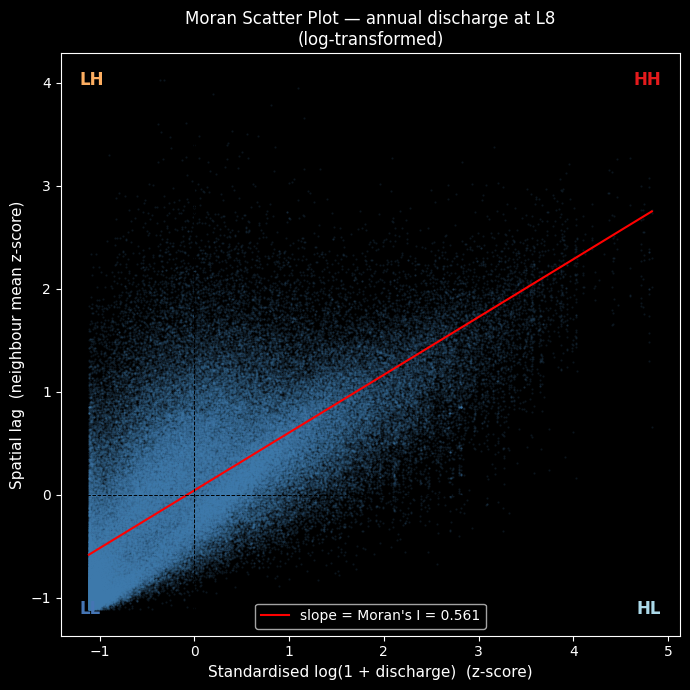

In [13]:
# Cell 26 — Moran scatter plot L8 (log)
y8_std = (y8_log - y8_log.mean()) / y8_log.std()
wy8    = libpysal.weights.lag_spatial(w8, y8_std)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y8_std, wy8, s=0.3, alpha=0.15, color='steelblue', rasterized=True)

m, b = np.polyfit(y8_std, wy8, 1)
x_line = np.linspace(y8_std.min(), y8_std.max(), 200)
ax.plot(x_line, m * x_line + b, color='red', linewidth=1.5,
        label=f"slope = Moran's I = {m:.3f}")

ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
ax.axvline(0, color='black', linewidth=0.7, linestyle='--')

ax.text(0.97, 0.97, 'HH', transform=ax.transAxes, ha='right', va='top',    fontsize=12, color='#e41a1c', fontweight='bold')
ax.text(0.03, 0.97, 'LH', transform=ax.transAxes, ha='left',  va='top',    fontsize=12, color='#fdae61', fontweight='bold')
ax.text(0.97, 0.03, 'HL', transform=ax.transAxes, ha='right', va='bottom', fontsize=12, color='#abd9e9', fontweight='bold')
ax.text(0.03, 0.03, 'LL', transform=ax.transAxes, ha='left',  va='bottom', fontsize=12, color='#4575b4', fontweight='bold')

ax.set_xlabel('Standardised log(1 + discharge)  (z-score)', fontsize=11)
ax.set_ylabel('Spatial lag  (neighbour mean z-score)', fontsize=11)
ax.set_title('Moran Scatter Plot — annual discharge at L8\n(log-transformed)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
print(f'Slope = {m:.4f}  (should equal Moran I log L8: {mi8_log.I:.4f})')

### Step 13 — LISA L8 (log)

In [14]:
# Cell 28 — LISA L8 (log)
t0 = time.time()
np.random.seed(SEED)
lisa8 = Moran_Local(y8_log, w8, permutations=999)
elapsed(t0, 'LISA L8')

labels8 = np.where(
    lisa8.p_sim < SIGNIFICANCE,
    np.array([quad_map[q] for q in lisa8.q]),
    'NS'
)
gdf8['lisa_class'] = labels8
gdf8['lisa_p']     = lisa8.p_sim
gdf8['lisa_I']     = lisa8.Is

counts8 = pd.Series(labels8).value_counts().reindex(['HH', 'LL', 'HL', 'LH', 'NS'], fill_value=0)
n8 = len(gdf8)
print('LISA L8 — log discharge (p < 0.05):')
for cls, n in counts8.items():
    print(f'  {cls}: {n:6,}  ({n / n8 * 100:.1f}%)')
print(f'  Total significant: {(labels8 != "NS").sum():,}  ({(labels8 != "NS").mean()*100:.1f}%)')

/Users/karlg/venvs/cedop/lib/python3.14/site-packages/esda/moran.py:1354: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim


### Step 14 — LISA cluster map L8

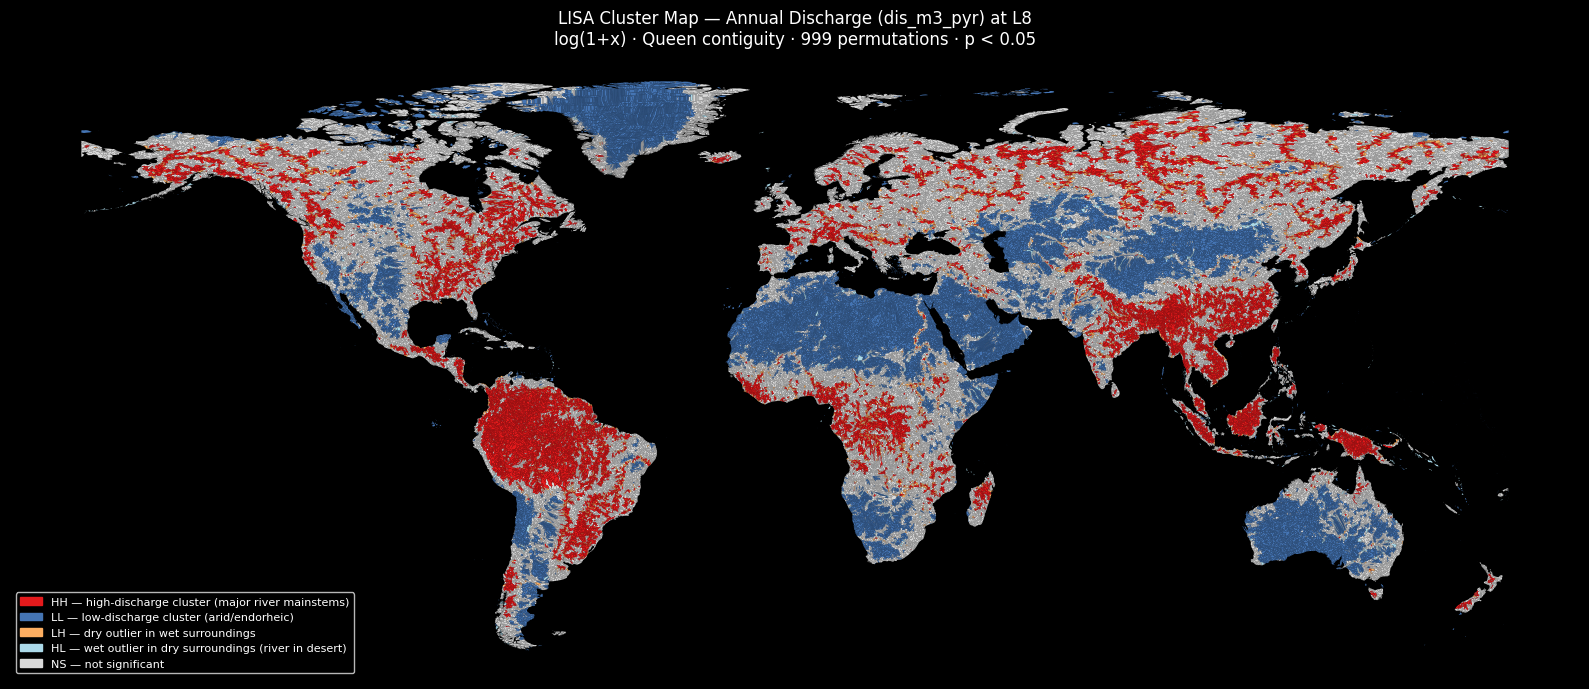

In [15]:
# Cell 30 — LISA cluster map L8
fig, ax = plt.subplots(figsize=(16, 9))
gdf8[gdf8['lisa_class'] == 'NS'].plot(ax=ax, color=COLOURS['NS'], linewidth=0)
for cls in ['LL', 'HH', 'HL', 'LH']:
    subset = gdf8[gdf8['lisa_class'] == cls]
    if len(subset):
        subset.plot(ax=ax, color=COLOURS[cls], linewidth=0)

legend_entries = {
    'HH — high-discharge cluster (major river mainstems)': COLOURS['HH'],
    'LL — low-discharge cluster (arid/endorheic)':         COLOURS['LL'],
    'LH — dry outlier in wet surroundings':                COLOURS['LH'],
    'HL — wet outlier in dry surroundings (river in desert)': COLOURS['HL'],
    'NS — not significant':                                COLOURS['NS'],
}
patches = [mpatches.Patch(color=c, label=l) for l, c in legend_entries.items()]
ax.legend(handles=patches, loc='lower left', fontsize=8, framealpha=0.9)
ax.set_title(
    'LISA Cluster Map — Annual Discharge (dis_m3_pyr) at L8\n'
    'log(1+x) · Queen contiguity · 999 permutations · p < 0.05',
    fontsize=12
)
ax.axis('off')
plt.tight_layout()
plt.savefig('/Users/karlg/Documents/repos/_cedop/spatial/basin08_queen_lisa_dis_python.png',
            dpi=150, bbox_inches='tight')
print('Saved → spatial/basin08_queen_lisa_dis_python.png')

---
## Part 3 — Cross-scale comparison

Compare discharge L6 vs L8, and both against aridity as reference. The structural question: does discharge behave more like aridity (scale-stable, smooth-gradient) or differently (scale-sensitive, topology-driven)?

In [16]:
# Cell 32 — cross-scale comparison
hh8 = (gdf8['lisa_class'] == 'HH').sum() / n8 * 100
ll8 = (gdf8['lisa_class'] == 'LL').sum() / n8 * 100
hl8 = (gdf8['lisa_class'] == 'HL').sum() / n8 * 100
lh8 = (gdf8['lisa_class'] == 'LH').sum() / n8 * 100
ns8 = (gdf8['lisa_class'] == 'NS').sum() / n8 * 100

# Aridity reference
ARI_L8 = dict(I_log=0.9924, HH=3.8, LL=30.9, HL=0.2, LH=0.0, NS=65.2)

print('=== Cross-scale comparison — dis_m3_pyr (log) ===')
print(f'{"":30s}  {"dis L6":>8}  {"dis L8":>8}  {"Δ scale":>8}  {"ari L6":>8}  {"ari L8":>8}')
print('-' * 76)
print(f'{"Moran I (log)":30s}  {mi6_log.I:>8.4f}  {mi8_log.I:>8.4f}  {mi8_log.I - mi6_log.I:>+8.4f}  {ARI_L6["I_log"]:>8.4f}  {ARI_L8["I_log"]:>8.4f}')
print(f'{"HH %":30s}  {hh6:>8.1f}  {hh8:>8.1f}  {hh8 - hh6:>+8.1f}  {ARI_L6["HH"]:>8.1f}  {ARI_L8["HH"]:>8.1f}')
print(f'{"LL %":30s}  {ll6:>8.1f}  {ll8:>8.1f}  {ll8 - ll6:>+8.1f}  {ARI_L6["LL"]:>8.1f}  {ARI_L8["LL"]:>8.1f}')
print(f'{"HL %":30s}  {hl6:>8.1f}  {hl8:>8.1f}  {hl8 - hl6:>+8.1f}  {ARI_L6["HL"]:>8.1f}  {ARI_L8["HL"]:>8.1f}')
print(f'{"LH %":30s}  {lh6:>8.1f}  {lh8:>8.1f}  {lh8 - lh6:>+8.1f}  {ARI_L6["LH"]:>8.1f}  {ARI_L8["LH"]:>8.1f}')
print(f'{"NS %":30s}  {ns6:>8.1f}  {ns8:>8.1f}  {ns8 - ns6:>+8.1f}  {ARI_L6["NS"]:>8.1f}  {ARI_L8["NS"]:>8.1f}')
print()
print('Key comparison: if discharge I << aridity I, network topology produces weaker')
print('autocorrelation than climate gradients. If HL% >> aridity HL%, watershed')
print('divides are creating more spatial outliers than climate transitions do.')

=== Cross-scale comparison — dis_m3_pyr (log) ===
                                  dis L6    dis L8   Δ scale    ari L6    ari L8
----------------------------------------------------------------------------
Moran I (log)                     0.5822    0.5629   -0.0193    0.9731    0.9924
HH %                                20.4      15.6      -4.8       4.6       3.8
LL %                                18.9      23.5      +4.6      30.0      30.9
HL %                                 0.8       0.3      -0.4       1.4       0.2
LH %                                 1.8       3.5      +1.7       0.0       0.0
NS %                                58.1      56.9      -1.1      64.0      65.2

Key comparison: if discharge I << aridity I, network topology produces weaker
autocorrelation than climate gradients. If HL% >> aridity HL%, watershed
divides are creating more spatial outliers than climate transitions do.
